<a href="https://colab.research.google.com/github/karthikeyan15-bit/deeplearning_repo/blob/main/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kushsheth/face-vae")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [00:14<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kushsheth/face-vae/versions/1


In [ ]:
import os #os is used to fetch file and multi-thread operations
import shutil # shutil is used have copy of the data
import numpy as np # numpy is used to list computation
import matplotlib.pyplot as plt #matplotlib.pyplot is you in visualization part

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model

In [ ]:
import os

# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
for file in files_in_dataset:
    if file=='celeba-dataset.zip':
      !unzip -q celeba-dataset.zip
    else:
      pass

#create a smaller Dataset (5000 image)
source_folder=os.path.join(path,"img_align_celeba","img_align_celeba")
destination_folder="celeba_small/face"
os.makedirs(destination_folder, exist_ok=True)
image=sorted(os.listdir(source_folder))[:5000]
for img in image:
    shutil.copy(
        os.path.join(source_folder,img),
        destination_folder
    )
print(destination_folder)

celeba_small/face


In [ ]:
image_size=(64,64)
batch_size=32

datagen=ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2
    )

In [ ]:
train_generator=datagen.flow_from_directory(
    'celeba_small',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='input',
    subset='training'
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator=datagen.flow_from_directory(
    'celeba_small',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='input',
    subset='validation'
)

Found 1000 images belonging to 1 classes.


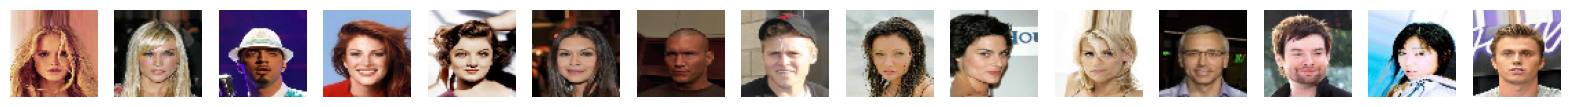

In [ ]:
images,_=next(train_generator)
plt.figure(figsize=(20,20))
for i in range(15):
    ax=plt.subplot(1,15,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [ ]:
input_img=Input(shape=(64,64,3))
x=Conv2D(64,(3,3),activation='relu',padding='same')
(input_img)
input_img=Input(shape=(64,64,3))

In [ ]:
from tensorflow.keras.layers import LeakyReLU # Added this import

input_img=Input(shape=(64, 64, 3))
x=Conv2D(64,(3,3),activation="relu",padding="same")(input_img)
x=LeakyReLU(negative_slope=0.01)(x) # Corrected usage: instantiate LeakyReLU and apply it to x
encoder=MaxPooling2D((2,2),padding="same")(x)

In [ ]:
#build decoder

x=Conv2D(32,(3,3),activation="relu",padding="same")(encoder)
x=UpSampling2D((2,2))(x)
decoder=Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)

In [ ]:
#model creation
# The original input_img variable was overwritten by a subsequent cell execution.
# To ensure the Model is built with the correct input layer that the decoder was built upon,
# we retrieve the source input from the decoder tensor.
true_input_img = tf.keras.utils.get_source_inputs(decoder)[0]
autoencoder = Model(true_input_img, decoder)

In [ ]:
#comiple model
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [ ]:
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123 (82.51 KB)

 Trainable params: 21,123 (82.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model
history=autoencoder.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.5234 - val_loss: 0.4880
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4854 - val_loss: 0.4843
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4817 - val_loss: 0.4812
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4798 - val_loss: 0.4795
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4789 - val_loss: 0.4788
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.4782 - val_loss: 0.4781
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4776 - val_loss: 0.4777
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4772 - val_loss: 0.4772
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.4767 - val_loss: 0.4768
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4765 - val_loss: 0.4765
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4760 - val_loss: 0.4762
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 

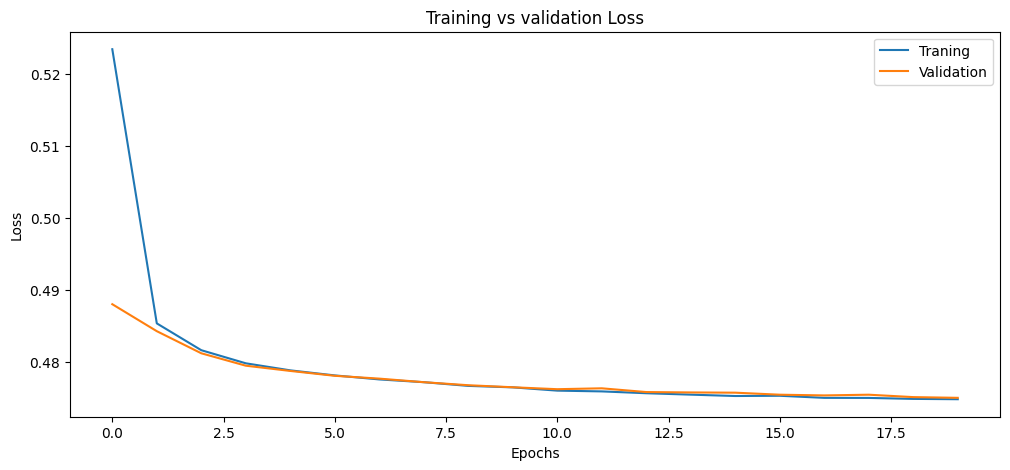

In [ ]:
#plot
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs validation Loss")
plt.legend(["Traning","Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


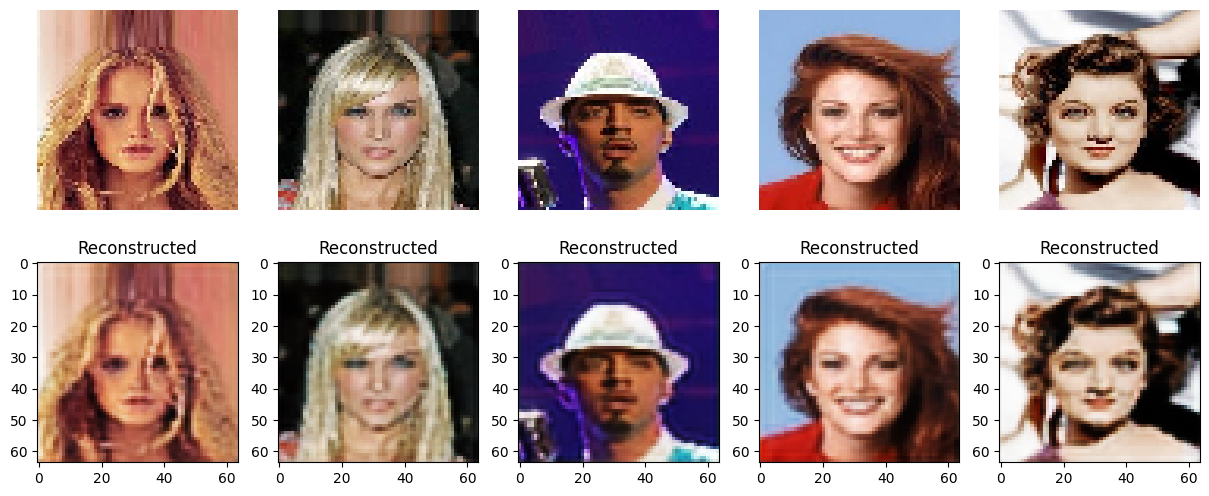

In [ ]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.axis('off')
  plt.subplot(2,n,i+1+n)
  plt.imshow(autoencoder.predict(images)[i])
  plt.title("Reconstructed")